TP3 SVM Valentin MASSONNIERE

Prétraitement du test en utilisant NLTK:
Cette procédure consiste en les points suivants :

• Combiner le titre et le contenu de l’article dans un seul champ.
• Mettre le texte en minuscules, le découper en tokens (mots).
• Ne conserver que les mots composés de lettres (en supprimant ainsi la ponctuation et
les nombres).
• Appliquer la lemmatisation.
• Supprimer les stop words

In [39]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt') 
nltk.download("punkt_tab")
nltk.download('wordnet')
nltk.download('stopwords') 
nltk.download('omw-1.4') 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Valentin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

1. Chargement des données

In [26]:
import pandas as pd

data = pd.read_csv("bbc-news-data.csv", sep="\t", encoding="utf-8")

data.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


2. Prétraitement du texte (Text Preprocessing)

In [27]:
data["raw_text"] = data["title"] + data["content"]

data.head()

,category,filename,title,content,raw_text
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,Ad sales boost Time Warner profit Quarterly pr...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,Dollar gains on Greenspan speech The dollar ha...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,Yukos unit buyer faces loan claim The owners o...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,High fuel prices hit BA's profits British Airw...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,Pernod takeover talk lifts Domecq Shares in UK...


Conversion en minuscules

In [31]:
data["raw_text"] = data["raw_text"].str.lower()

data.head()

,category,filename,title,content,raw_text,tokens
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,ad sales boost time warner profit quarterly pr...,"[Ad, sales, boost, Time, Warner, profit, Quart..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,dollar gains on greenspan speech the dollar ha...,"[Dollar, gains, on, Greenspan, speech, The, do..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,yukos unit buyer faces loan claim the owners o...,"[Yukos, unit, buyer, faces, loan, claim, The, ..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,high fuel prices hit ba's profits british airw...,"[High, fuel, prices, hit, BA, 's, profits, Bri..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,pernod takeover talk lifts domecq shares in uk...,"[Pernod, takeover, talk, lifts, Domecq, Shares..."


Tokenization (découpage en mots)

In [32]:
data["tokens"] = data["raw_text"].apply(word_tokenize)

data.head()

,category,filename,title,content,raw_text,tokens
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,ad sales boost time warner profit quarterly pr...,"[ad, sales, boost, time, warner, profit, quart..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,dollar gains on greenspan speech the dollar ha...,"[dollar, gains, on, greenspan, speech, the, do..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,yukos unit buyer faces loan claim the owners o...,"[yukos, unit, buyer, faces, loan, claim, the, ..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,high fuel prices hit ba's profits british airw...,"[high, fuel, prices, hit, ba, 's, profits, bri..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,pernod takeover talk lifts domecq shares in uk...,"[pernod, takeover, talk, lifts, domecq, shares..."


Filtrage : ne garder que les lettres

In [35]:
data["clean_text"] = data["raw_text"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

data.head()

,category,filename,title,content,raw_text,tokens,clean_text
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,ad sales boost time warner profit quarterly pr...,"[ad, sales, boost, time, warner, profit, quart...",ad sales boost time warner profit quarterly pr...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,dollar gains on greenspan speech the dollar ha...,"[dollar, gains, on, greenspan, speech, the, do...",dollar gains on greenspan speech the dollar ha...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,yukos unit buyer faces loan claim the owners o...,"[yukos, unit, buyer, faces, loan, claim, the, ...",yukos unit buyer faces loan claim the owners o...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,high fuel prices hit ba's profits british airw...,"[high, fuel, prices, hit, ba, 's, profits, bri...",high fuel prices hit bas profits british airwa...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,pernod takeover talk lifts domecq shares in uk...,"[pernod, takeover, talk, lifts, domecq, shares...",pernod takeover talk lifts domecq shares in uk...


Suppression des stop words

In [36]:
swords = set(stopwords.words("english"))

data["tokens_no_stop"] = data["tokens"].apply(
    lambda tokens: [t for t in tokens if t.lower() not in swords]
)

data.head()

,category,filename,title,content,raw_text,tokens,clean_text,tokens_no_stop
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,ad sales boost time warner profit quarterly pr...,"[ad, sales, boost, time, warner, profit, quart...",ad sales boost time warner profit quarterly pr...,"[ad, sales, boost, time, warner, profit, quart..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,dollar gains on greenspan speech the dollar ha...,"[dollar, gains, on, greenspan, speech, the, do...",dollar gains on greenspan speech the dollar ha...,"[dollar, gains, greenspan, speech, dollar, hit..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,yukos unit buyer faces loan claim the owners o...,"[yukos, unit, buyer, faces, loan, claim, the, ...",yukos unit buyer faces loan claim the owners o...,"[yukos, unit, buyer, faces, loan, claim, owner..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,high fuel prices hit ba's profits british airw...,"[high, fuel, prices, hit, ba, 's, profits, bri...",high fuel prices hit bas profits british airwa...,"[high, fuel, prices, hit, ba, 's, profits, bri..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,pernod takeover talk lifts domecq shares in uk...,"[pernod, takeover, talk, lifts, domecq, shares...",pernod takeover talk lifts domecq shares in uk...,"[pernod, takeover, talk, lifts, domecq, shares..."


Lemmatisation

In [40]:
lemmatizer = WordNetLemmatizer()

data["lemmas"] = data["tokens_no_stop"].apply(
    lambda tokens: [lemmatizer.lemmatize(t) for t in tokens]
)

data.head()

,category,filename,title,content,raw_text,tokens,clean_text,tokens_no_stop,lemmas
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,ad sales boost time warner profit quarterly pr...,"[ad, sales, boost, time, warner, profit, quart...",ad sales boost time warner profit quarterly pr...,"[ad, sales, boost, time, warner, profit, quart...","[ad, sale, boost, time, warner, profit, quarte..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,dollar gains on greenspan speech the dollar ha...,"[dollar, gains, on, greenspan, speech, the, do...",dollar gains on greenspan speech the dollar ha...,"[dollar, gains, greenspan, speech, dollar, hit...","[dollar, gain, greenspan, speech, dollar, hit,..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,yukos unit buyer faces loan claim the owners o...,"[yukos, unit, buyer, faces, loan, claim, the, ...",yukos unit buyer faces loan claim the owners o...,"[yukos, unit, buyer, faces, loan, claim, owner...","[yukos, unit, buyer, face, loan, claim, owner,..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,high fuel prices hit ba's profits british airw...,"[high, fuel, prices, hit, ba, 's, profits, bri...",high fuel prices hit bas profits british airwa...,"[high, fuel, prices, hit, ba, 's, profits, bri...","[high, fuel, price, hit, ba, 's, profit, briti..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,pernod takeover talk lifts domecq shares in uk...,"[pernod, takeover, talk, lifts, domecq, shares...",pernod takeover talk lifts domecq shares in uk...,"[pernod, takeover, talk, lifts, domecq, shares...","[pernod, takeover, talk, lift, domecq, share, ..."


Résultat final

In [41]:
data["lemmas"]

0       [ad, sale, boost, time, warner, profit, quarte...
1       [dollar, gain, greenspan, speech, dollar, hit,...
2       [yukos, unit, buyer, face, loan, claim, owner,...
3       [high, fuel, price, hit, ba, 's, profit, briti...
4       [pernod, takeover, talk, lift, domecq, share, ...
                              ...                        
2220    [bt, program, beat, dialler, scam, bt, introdu...
2221    [spam, e-mail, tempt, net, shopper, computer, ...
2222    [careful, code, new, european, directive, coul...
2223    [u, cyber, security, chief, resigns, man, maki...
2224    [losing, online, gaming, online, role, playing...
Name: lemmas, Length: 2225, dtype: object

3. Vectorisation

In [42]:
data["lemmas_str"] = data["lemmas"].apply(lambda lst: " ".join(lst))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data["lemmas_str"])

4. Séparation Train / Test

In [43]:
from sklearn.model_selection import train_test_split

X = vectorizer.fit_transform(data["lemmas_str"])
y = data["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=42,    
    stratify=y
)     

print(y_train.value_counts())
print(y_test.value_counts())

category
sport            409
business         408
politics         333
tech             321
entertainment    309
Name: count, dtype: int64
category
business         102
sport            102
politics          84
tech              80
entertainment     77
Name: count, dtype: int64


5. Entraînement du modèle SVM

In [44]:
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1.0, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

6. Test et Évaluation du modèle

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy : 0.9865
               precision    recall  f1-score   support

     business       1.00      0.96      0.98       102
entertainment       0.97      1.00      0.99        77
     politics       0.99      0.98      0.98        84
        sport       0.99      1.00      1.00       102
         tech       0.98      1.00      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445

[[ 98   1   1   1   1]
 [  0  77   0   0   0]
 [  0   1  82   0   1]
 [  0   0   0 102   0]
 [  0   0   0   0  80]]


Visualisation de la matrice

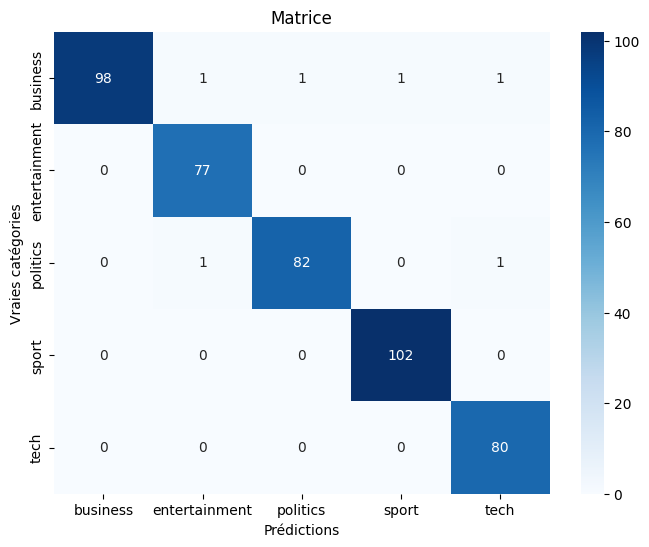

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=y.unique(), yticklabels=y.unique(), cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Vraies catégories")
plt.title("Matrice")
plt.show()

7. Analyse des performances

Presque toutes les valeurs sont sur la diagonale et il y a une bonne précision et recul.
Il n'y a pas eu d'erreurs sur  les catégories sports et tech. 
4 erreurs/102 pour le business et 2/84 pour la politique.

Il y a une accuracy globale de 98 % avec une recall de 96 %

Le modèle fonctionne très bien et les erreurs sont rares et simples à analyser.